# Call Center Performance Analysis
## Data Cleaning

In [1203]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st

In [1204]:
# Read the datasets
users_plan= pd.read_csv("telecom_clients.csv")
calls= pd.read_csv("telecom_dataset_new.csv")

In [1205]:
# Initial exploration of the users_plan Dataframe
print(users_plan.head())

   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29
3   167097           A  2019-09-01
4   168193           A  2019-10-16


In [1206]:
print(users_plan.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB
None


In [1207]:
# Data type conversion of the date_start column: From string to Datetime64
users_plan['date_start']= pd.to_datetime(users_plan['date_start'])

In [1208]:
# Verification of appropriate data types
print(users_plan.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 17.3+ KB
None


In [1209]:
# Duplicate value verification
print(users_plan.duplicated().sum())

0


In [1210]:
# Verification of missing values
print(users_plan.isnull().sum())

user_id        0
tariff_plan    0
date_start     0
dtype: int64


In [1211]:
# Descriptive statistics of the users_plan Dataframe
print(users_plan.describe())

             user_id                     date_start
count     732.000000                            732
mean   167431.927596  2019-09-14 16:39:20.655737600
min    166373.000000            2019-08-01 00:00:00
25%    166900.750000            2019-08-23 00:00:00
50%    167432.000000            2019-09-16 00:00:00
75%    167973.000000            2019-10-08 00:00:00
max    168606.000000            2019-10-31 00:00:00
std       633.810383                            NaN


In [1212]:
# Initial exploration of the Dataframe calls
print(calls.head())

   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
3   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
4   166377  2019-08-05 00:00:00+03:00       out    False     880022.0   

   is_missed_call  calls_count  call_duration  total_call_duration  
0            True            2              0                    4  
1            True            3              0                    5  
2            True            1              0                    1  
3           False            1             10                   18  
4            True            3              0                   25  


In [1213]:
print(calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None


In [1214]:
# Converting the data type of the date column: From string to Datetime64
calls['date']= pd.to_datetime(calls['date'])

In [1215]:
# Verification of appropriate data types
print(calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              53902 non-null  int64                    
 1   date                 53902 non-null  datetime64[ns, UTC+03:00]
 2   direction            53902 non-null  object                   
 3   internal             53785 non-null  object                   
 4   operator_id          45730 non-null  float64                  
 5   is_missed_call       53902 non-null  bool                     
 6   calls_count          53902 non-null  int64                    
 7   call_duration        53902 non-null  int64                    
 8   total_call_duration  53902 non-null  int64                    
dtypes: bool(1), datetime64[ns, UTC+03:00](1), float64(1), int64(4), object(2)
memory usage: 3.3+ MB
None


In [1216]:
# Duplicate value check
print(calls.duplicated().sum())

4900


In [1217]:
# Checking for null values
print(calls.isnull().sum())

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64


In [1218]:
# Duplicate value check
print(calls['operator_id'].value_counts())

operator_id
901884.0    348
901880.0    337
893804.0    325
885876.0    319
891410.0    290
           ... 
911152.0      1
891250.0      1
962904.0      1
940512.0      1
937772.0      1
Name: count, Length: 1092, dtype: int64


In [1219]:
missed_calls= calls[calls['operator_id'].isnull()]
print(len(missed_calls))
print(f"Are these missed calls? {missed_calls['is_missed_call'].value_counts()}")

8172
Are these missed calls? is_missed_call
True     8050
False     122
Name: count, dtype: int64


# Observation
Based on this, it can be said that of the 8,172 calls with a null operator_id, 8,050 are missed calls (98.5%). This is very strong evidence of system inefficiency.

In [1220]:
# Duplicate values: Example
duplicates= calls[calls.duplicated(keep=False)]
print(f"First duplicates:")
print(duplicates.head(10))

First duplicates:
    user_id                      date direction internal  operator_id  \
6    166377 2019-08-05 00:00:00+03:00       out    False     880020.0   
8    166377 2019-08-05 00:00:00+03:00       out    False     880020.0   
27   166377 2019-08-12 00:00:00+03:00        in    False          NaN   
28   166377 2019-08-12 00:00:00+03:00        in    False          NaN   
38   166377 2019-08-14 00:00:00+03:00        in    False          NaN   
43   166377 2019-08-14 00:00:00+03:00       out    False     880026.0   
44   166377 2019-08-14 00:00:00+03:00       out    False     880026.0   
45   166377 2019-08-14 00:00:00+03:00        in    False          NaN   
46   166377 2019-08-15 00:00:00+03:00       out    False     880026.0   
51   166377 2019-08-15 00:00:00+03:00       out    False     880026.0   

    is_missed_call  calls_count  call_duration  total_call_duration  
6             True            8              0                   50  
8             True            8       

# Studies of inefficient operators

In [1221]:
# Call volume analysis: Number of outgoing and incoming calls
calls_in= calls.groupby('direction')['calls_count'].count().reset_index()
print(calls_in)

  direction  calls_count
0        in        21985
1       out        31917


In [1222]:
# Number of internal and external calls
calls_internal_external= calls.groupby('internal')['calls_count'].count().reset_index()
print(calls_internal_external)

   internal  calls_count
0     False        47621
1      True         6164


In [1223]:
# Call duration analysis: Distribution
print(calls['call_duration'].value_counts())

call_duration
0        23263
1          200
7          144
15         126
13         125
         ...  
10061        1
57988        1
12935        1
1108         1
3296         1
Name: count, Length: 5373, dtype: int64


In [1224]:
# Statistical analysis of the call duration column
print(calls['call_duration'].describe())

count     53902.000000
mean        866.684427
std        3731.791202
min           0.000000
25%           0.000000
50%          38.000000
75%         572.000000
max      144395.000000
Name: call_duration, dtype: float64


In [1225]:
# Analysis of missed calls: Distribution and functionality of missed calls
missed_calls_internal= calls.groupby('is_missed_call')['internal'].count().reset_index()
print(missed_calls_internal)

   is_missed_call  internal
0           False     30275
1            True     23510


In [1226]:
# Call analysis: Check if missed calls are more internal than external
missed_calls_direction= calls.groupby('direction')['is_missed_call'].count().reset_index()
print(missed_calls_direction)

  direction  is_missed_call
0        in           21985
1       out           31917


In [1227]:
# Percentage and distribution of missed calls
percentage_missed_calls= calls['is_missed_call'].value_counts(normalize=True) * 100
print(percentage_missed_calls)

is_missed_call
False    56.276205
True     43.723795
Name: proportion, dtype: float64


# Observation
56.2% of the calls were missed calls, which may indicate problems with operator responsiveness.

In [1228]:
# Unique values ​​in the operator_id column
print(calls['operator_id'].value_counts())

operator_id
901884.0    348
901880.0    337
893804.0    325
885876.0    319
891410.0    290
           ... 
911152.0      1
891250.0      1
962904.0      1
940512.0      1
937772.0      1
Name: count, Length: 1092, dtype: int64


In [1229]:
# Analysis by individual operator
operator_performance = calls[calls['operator_id'].notna()].groupby('operator_id').agg({
    'is_missed_call': ['count', 'sum'],  
    'call_duration': 'mean',            
    'direction': lambda x: (x == 'out').sum()  
}).reset_index()
operator_performance.columns=['operator_id','total_calls', 'missed_calls', 'avg_call_duration', 'outgoing_calls']
print(operator_performance)

      operator_id  total_calls  missed_calls  avg_call_duration  \
0        879896.0          128            50         650.476562   
1        879898.0          251           100        1111.067729   
2        880020.0           22             7         104.090909   
3        880022.0           76            33         240.842105   
4        880026.0          198            94         856.939394   
...           ...          ...           ...                ...   
1087     972410.0            4             2         944.250000   
1088     972412.0            5             2         699.600000   
1089     972460.0            9             3         257.888889   
1090     973120.0            2             1           2.500000   
1091     973286.0            1             0          17.000000   

      outgoing_calls  
0                105  
1                187  
2                 14  
3                 68  
4                179  
...              ...  
1087               4  
1088       

In [1230]:
# Percentage of missed calls per operator
missed_calls_per_operator= (operator_performance['missed_calls'] / operator_performance['total_calls']) * 100
print(missed_calls_per_operator.head(10).sort_values(ascending=False))

7    87.500000
6    57.142857
4    47.474747
3    43.421053
5    40.265487
1    39.840637
0    39.062500
9    33.333333
2    31.818182
8     0.000000
dtype: float64


In [1231]:
print(operator_performance.head())

   operator_id  total_calls  missed_calls  avg_call_duration  outgoing_calls
0     879896.0          128            50         650.476562             105
1     879898.0          251           100        1111.067729             187
2     880020.0           22             7         104.090909              14
3     880022.0           76            33         240.842105              68
4     880026.0          198            94         856.939394             179


In [1232]:
# Creation of a column for the percentage of missed calls per operator
operator_performance['missed_calls_percentage'] = (operator_performance['missed_calls'] / operator_performance['total_calls']) * 100

In [1233]:
# Verification of the newly created column called missed_calls_percentage
print(operator_performance.head())

   operator_id  total_calls  missed_calls  avg_call_duration  outgoing_calls  \
0     879896.0          128            50         650.476562             105   
1     879898.0          251           100        1111.067729             187   
2     880020.0           22             7         104.090909              14   
3     880022.0           76            33         240.842105              68   
4     880026.0          198            94         856.939394             179   

   missed_calls_percentage  
0                39.062500  
1                39.840637  
2                31.818182  
3                43.421053  
4                47.474747  


# Criteria for determining when an operator is ineffective
- Long wait time: > 90 seconds
- High percentage of missed calls: > 50%
- Few outgoing calls: < 20 calls

In [1234]:
# Statistical study of the total_calls column
print(operator_performance['total_calls'].describe())

count    1092.000000
mean       41.877289
std        54.080833
min         1.000000
25%         6.000000
50%        21.000000
75%        54.250000
max       348.000000
Name: total_calls, dtype: float64


In [1235]:
# Operators with many missed calls
high_missed_calls= operator_performance[operator_performance['missed_calls_percentage'] > 50]
print(high_missed_calls.head())

    operator_id  total_calls  missed_calls  avg_call_duration  outgoing_calls  \
6      880240.0           14             8         275.928571              14   
7      881278.0            8             7          58.125000               8   
15     883018.0            1             1           0.000000               1   
27     885682.0            3             3           0.000000               3   
30     886146.0           19            10         311.368421              18   

    missed_calls_percentage  
6                 57.142857  
7                 87.500000  
15               100.000000  
27               100.000000  
30                52.631579  


In [1236]:
# Operators with long waiting times
long_wait_times = operator_performance[operator_performance['avg_call_duration'] > 90]
print(long_wait_times.head())

   operator_id  total_calls  missed_calls  avg_call_duration  outgoing_calls  \
0     879896.0          128            50         650.476562             105   
1     879898.0          251           100        1111.067729             187   
2     880020.0           22             7         104.090909              14   
3     880022.0           76            33         240.842105              68   
4     880026.0          198            94         856.939394             179   

   missed_calls_percentage  
0                39.062500  
1                39.840637  
2                31.818182  
3                43.421053  
4                47.474747  


In [1237]:
# Operators with few outgoing calls
low_outgoing_calls = operator_performance[operator_performance['outgoing_calls'] < 20]
print(low_outgoing_calls.head())

   operator_id  total_calls  missed_calls  avg_call_duration  outgoing_calls  \
2     880020.0           22             7         104.090909              14   
6     880240.0           14             8         275.928571              14   
7     881278.0            8             7          58.125000               8   
8     882476.0            3             0          64.000000               0   
9     882478.0            3             1          22.666667               1   

   missed_calls_percentage  
2                31.818182  
6                57.142857  
7                87.500000  
8                 0.000000  
9                33.333333  


In [1238]:
# How many operators are there in each category
print(f"Operators with > 50% missed calls: {len(high_missed_calls)}")
print(f"Operators with > 90s average time: {len(long_wait_times)}")  
print(f"Operators with < 20 outgoing calls: {len(low_outgoing_calls)}")

Operators with > 50% missed calls: 154
Operators with > 90s average time: 795
Operators with < 20 outgoing calls: 635


# Observation
The analysis shows that the most common problem among operators is the long wait time for incoming calls. This suggests possible issues with call distribution or overloading of some operators.

In [1239]:
# Are there operators who are ineffective in multiple areas?

# Operators with multiple problems
multiple_issues = operator_performance[
    (operator_performance['missed_calls_percentage'] > 50) & 
    (operator_performance['avg_call_duration'] > 90) & 
    (operator_performance['outgoing_calls'] < 20)
]
print(f"Operators with the 3 problems: {len(multiple_issues)}")

Operators with the 3 problems: 24


# Observation
Twenty-four operators were identified who simultaneously exhibit all three analyzed problems: a high proportion of missed calls, long call times, and few outgoing calls. These cases are especially critical, as they reflect inefficiency in multiple aspects of performance, and should therefore be prioritized for review, training, or more detailed follow-up.

In [1240]:
# Do operators with high missed calls also have long wait times?

# Intersection: High missed calls and long wait times
missed_and_long_wait = operator_performance[
    (operator_performance['missed_calls_percentage'] > 50) & 
    (operator_performance['avg_call_duration'] > 90)
]
print(f"Operators with both problems: {len(missed_and_long_wait)}")

Operators with both problems: 87


# Observation
Eighty-seven operators were identified who simultaneously exhibit two of the analyzed problems. Although their performance is not critical in all aspects, the presence of multiple inefficiency indicators suggests that they could be affecting service quality. Therefore, it would be advisable to analyze the causes in greater detail and consider improvement or follow-up measures.

In [1241]:
# Do carriers with low outbound call volume compensate with better quality in other areas?

# Carriers with low outbound call volume
low_outgoing = operator_performance[operator_performance['outgoing_calls'] < 20]

# Analizar su calidad en otros aspectos
print("Operators with few outgoing calls:")
print(f"Average number of missed calls: {low_outgoing['missed_calls_percentage'].mean():.2f}%")
print(f"Average call duration: {low_outgoing['avg_call_duration'].mean():.2f} segundos")

Operators with few outgoing calls:
Average number of missed calls: 26.54%
Average call duration: 328.54 segundos


# Observation
Operators with few outbound calls have an average of 26.54% missed calls, a figure slightly lower than the overall average. Furthermore, their average call duration is 328.54 seconds (approximately 5.5 minutes), which is considerably shorter than the global average. This could indicate that these operators are less involved in overall call activity or handle shorter interactions.

In [1242]:
# Overall average for comparison
print("\nOverall average of all operators:")
print(f"Average number of missed calls: {operator_performance['missed_calls_percentage'].mean():.2f}%")
print(f"Average duration: {operator_performance['avg_call_duration'].mean():.2f} segundos")


Overall average of all operators:
Average number of missed calls: 31.43%
Average duration: 648.21 segundos


# Observation
On average, operators have a 31.43% missed call rate, indicating that approximately 3 out of every 10 calls are not answered. Additionally, the average call duration is 648.21 seconds (around 10.8 minutes). These values ​​serve as a benchmark to identify operators whose performance is below or above the overall team average.

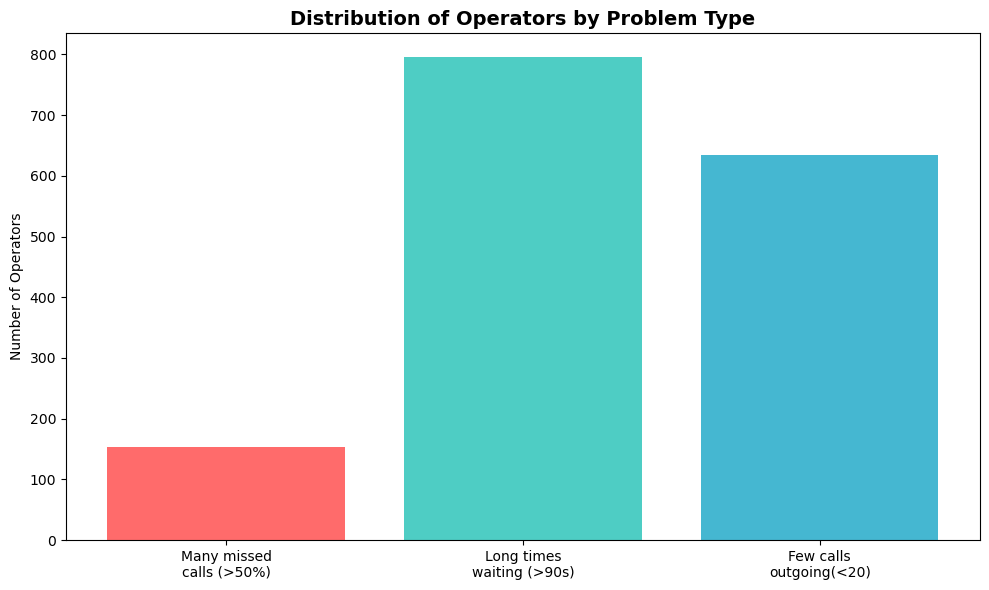

In [1243]:
# Data for the first graph
categories = ['Many missed\ncalls (>50%)', 'Long times\nwaiting (>90s)', 'Few calls\noutgoing(<20)']
counts = [len(high_missed_calls), len(long_wait_times), len(low_outgoing_calls)]

# Crear el gráfico
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
plt.title('Distribution of Operators by Problem Type', fontsize=14, fontweight='bold')
plt.ylabel('Number of Operators')
plt.tight_layout()
plt.show()

# Observation
The graph shows that the category with the highest number of operators corresponds to those with long wait times (greater than 90 seconds). This suggests that this is the most frequent problem among operators, which could indicate inefficiencies in call management and represents a key point that should be prioritized to improve service performance.

In [1244]:
# Calculate averages for each group
grupos = ['Normal\noperators', 'Many missed\ncalls', 'Long times\nwaiting', 'Few calls\noutgoing']

# Normal operators (no serious problems)
operadores_normales = operator_performance[
    (operator_performance['missed_calls_percentage'] <= 50) & 
    (operator_performance['avg_call_duration'] <= 90) & 
    (operator_performance['outgoing_calls'] >= 20)]

In [1245]:
# Creation of a dictionary with all the groups
groups = {
    'All': operator_performance,
    'High losses': high_missed_calls,
    'Long times': long_wait_times,
    'Few outgoings': low_outgoing_calls}

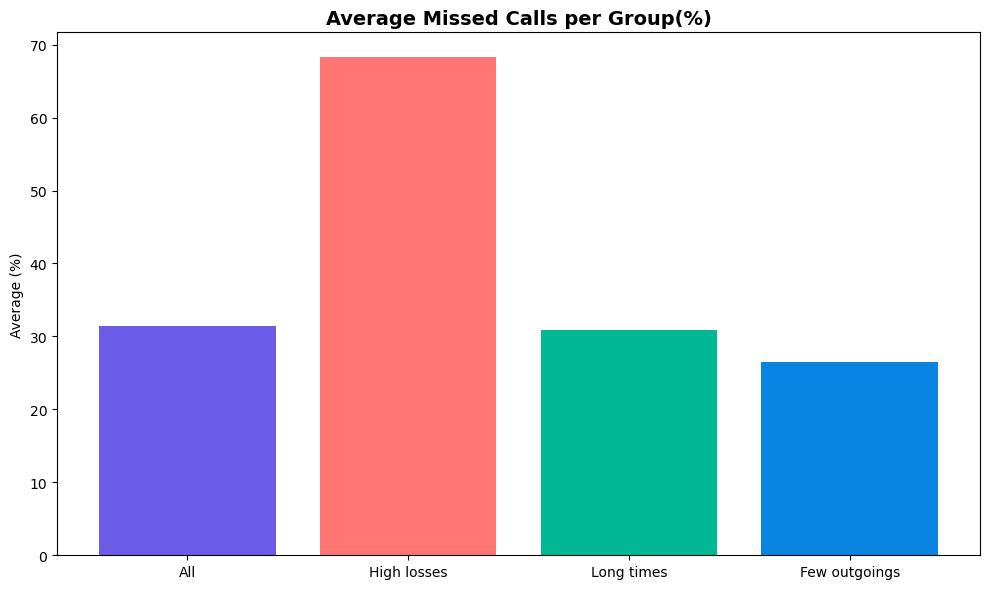

In [1246]:
# Calculate average missed calls per group
missed_means = [group['missed_calls_percentage'].mean() for group in groups.values()]
group_names = list(groups.keys())

plt.figure(figsize=(10, 6))
bars = plt.bar(group_names, missed_means, color=['#6c5ce7','#ff7675','#00b894','#0984e3'])
plt.title('Average Missed Calls per Group(%)', fontsize=14, fontweight='bold')
plt.ylabel('Average (%)')
plt.tight_layout()
plt.show()

# Observation
It is evident that the highest average of missed calls corresponds to the "High Loss" group, as defined in the operator group dictionary. This group has an average of nearly 70% missed calls, which is considerably higher compared to the "Long Call Times" and "Few Outgoing Calls" groups, indicating that the greatest problem in terms of unanswered calls is concentrated in this group of operators.

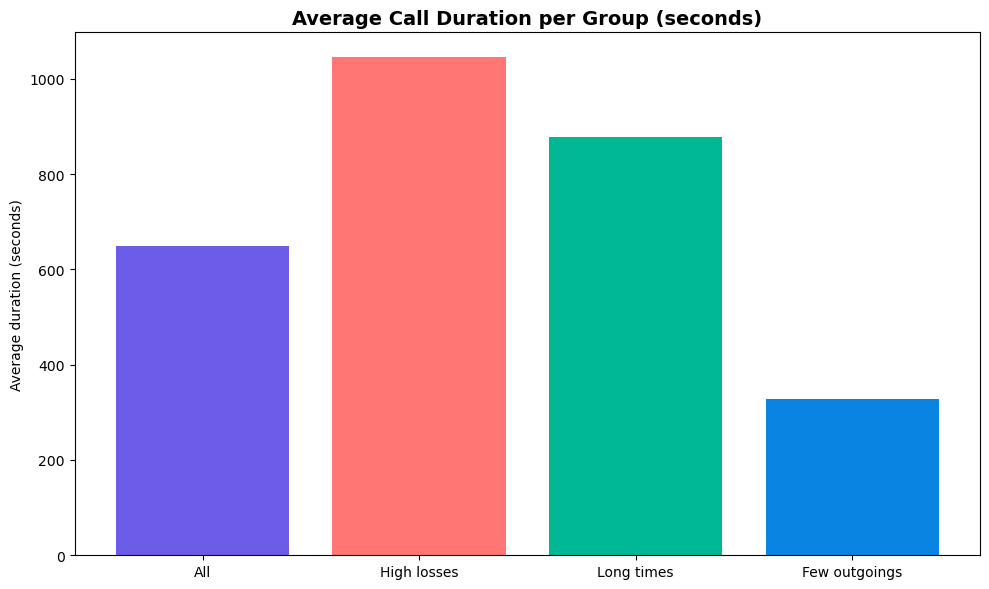

In [1247]:
# Calculate average duration per group
duration_means = [group['avg_call_duration'].mean() for group in groups.values()]

plt.figure(figsize=(10, 6))
bars = plt.bar(group_names, duration_means, color=['#6c5ce7','#ff7675','#00b894','#0984e3'])
plt.title('Average Call Duration per Group (seconds)', fontsize=14, fontweight='bold')
plt.ylabel('Average duration (seconds)')
plt.tight_layout()
plt.show()

# Hypothesis Testing
- Null Hypothesis (H0): There is no difference in the percentage of missed calls.

- Alternative Hypothesis (H1): Operators with longer wait times have more missed calls.


In [1248]:
# Define the groups for comparison
high_time_operators= operator_performance[operator_performance['avg_call_duration'] > 90]
normal_time_operators= operator_performance[operator_performance['avg_call_duration'] <= 90]

In [1249]:
print("HYPOTHESIS 1: LONG TIMES vs MISSED CALLS")
print(f"Operators with long times (> 90s): {len(high_time_operators)}")
print(f"Operators with normal times (≤ 90s):{len(normal_time_operators)}")

print(f"\nAverage missed calls - Long wait times: {high_time_operators['missed_calls_percentage'].mean():.2f}%")
print(f"Average missed calls - Normal times: {normal_time_operators['missed_calls_percentage'].mean():.2f}%")

HYPOTHESIS 1: LONG TIMES vs MISSED CALLS
Operators with long times (> 90s): 795
Operators with normal times (≤ 90s):297

Average missed calls - Long wait times: 30.87%
Average missed calls - Normal times: 32.94%


In [1250]:
# Hypothesis test

alpha= 0.05
t_stat, p_value= st.ttest_ind( high_time_operators['missed_calls_percentage'], 
normal_time_operators['missed_calls_percentage'])
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Significance level: {alpha}")


if p_value < alpha:
    print(f"The null hypothesis is rejected because there is a statistically significant difference.")
else:
    print(f"The null hypothesis is not rejected because there is insufficient evidence of a significant difference.")


t-statistic: -1.3178
p-value: 0.187838
Significance level: 0.05
The null hypothesis is not rejected because there is insufficient evidence of a significant difference.


## Business Recommendations:

### 1. Evaluate Operational Processes

A high number of operators with long wait times suggests inefficiencies in internal workflows.

**Recommendation:**
- Review call handling processes
- Identify unnecessary steps
- Simplify complex procedures

**Business Impact:**
- Reduced call duration  
- Increased service capacity  
- Lower customer wait times  

---

### 2. Improve Technological Infrastructure

Long wait times may be caused by slow or inefficient systems such as CRM tools or call management platforms.

**Recommendation:**
- Evaluate system performance
- Optimize or upgrade slow tools

**Business Impact:**
- Improved operational efficiency  
- Reduced frustration for operators and customers  
- Increased team productivity  

---

### 3. Identify and Eliminate Bottlenecks

The presence of 795 operators with high wait times indicates critical bottlenecks.

**Recommendation:**
- Map workflows to detect congestion points  
- Remove unnecessary steps  
- Optimize limiting processes  

**Business Impact:**
- Elimination of operational bottlenecks  
- Improved service flow  
- Faster response times  

---


## Business Impact

This project helps organizations:

- Improve customer experience  
- Optimize internal operations  
- Increase efficiency and productivity  
- Make data-driven decisions  

---

